<a href="https://colab.research.google.com/github/Amri1003/Machine_Learning_Projects/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import the library

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns






In [ ]:
data=pd.read_csv('/content/Mall_customers.csv')

data






,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
# create input data

X=data.iloc[:,3:]

X






,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


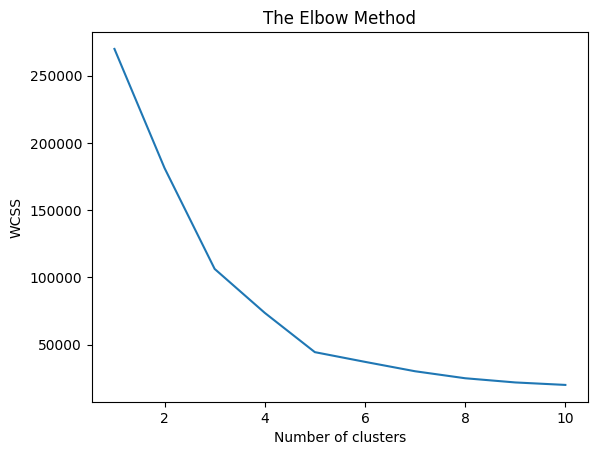

In [ ]:
# to find optimal num of clusters, elbow method

from sklearn.cluster import KMeans

wcss=[]

for i in range(1,11):

    model=KMeans(n_clusters=i,n_init=10,random_state=42)

    model.fit(X)

    wcss.append(model.inertia_)

plt.plot(range(1,11),wcss)

plt.title('The Elbow Method')

plt.xlabel('Number of clusters')

plt.ylabel('WCSS')

plt.show()






In [ ]:
# Apply clustering with optimal number of 5 clusters

from sklearn.cluster import KMeans

model=KMeans(n_clusters=5,n_init=10,random_state=42)

y_kmeans=model.fit_predict(X)

print(y_kmeans)






[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [ ]:
# print cluster centers

model.cluster_centers_






array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

In [ ]:
# Num of data points in each cluster

pred_df=pd.DataFrame(y_kmeans.tolist())

pred_df.value_counts()






,count
0,
0,81
1,39
3,35
4,23
2,22


In [ ]:
data['Cluster_num']=y_kmeans
#It should be: data['Cluster_num']=y_means











In [ ]:
data[data['Cluster_num']==0]






,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_num
43,44,Female,31,39,61,0
46,47,Female,50,40,55,0
47,48,Female,27,40,47,0
48,49,Female,29,40,42,0
49,50,Female,31,40,42,0
...,...,...,...,...,...,...
121,122,Female,38,67,40,0
122,123,Female,40,69,58,0
126,127,Male,43,71,35,0
132,133,Female,25,72,34,0


In [ ]:
data=pd.read_csv('Mall_customers.csv')

df=data.copy()






In [ ]:
X=df.iloc[:,3:].values

#X






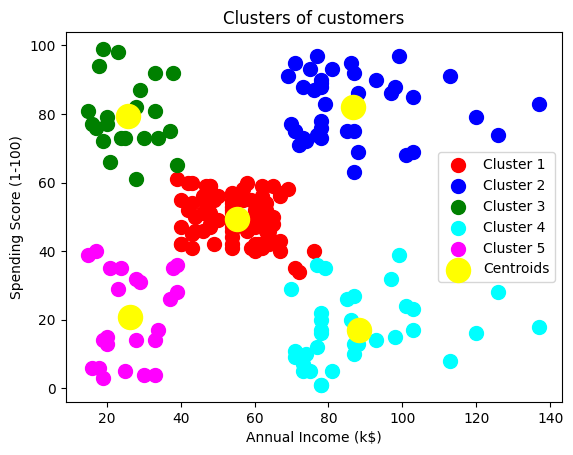

In [ ]:
# Visualize the clusters

plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')

plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')

plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')

plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=100, c='cyan', label='Cluster 4')

plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=100, c='magenta', label='Cluster 5')

plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids')

plt.title('Clusters of customers')

plt.xlabel('Annual Income (k$)')

plt.ylabel('Spending Score (1-100)')

plt.legend()

plt.show()






In [ ]:
from sklearn.metrics import silhouette_score

silhouette_score_kmeans=silhouette_score(X,y_kmeans)

print(silhouette_score_kmeans)






0.553931997444648


Silhouette score for 2 clusters: 0.2968969162503008
Silhouette score for 3 clusters: 0.46761358158775435
Silhouette score for 4 clusters: 0.4931963109249047
Silhouette score for 5 clusters: 0.553931997444648
Silhouette score for 6 clusters: 0.53976103063432
Silhouette score for 7 clusters: 0.5288104473798049
Silhouette score for 8 clusters: 0.45481197931195283
Silhouette score for 9 clusters: 0.4561091950997367
Silhouette score for 10 clusters: 0.4410568674364981


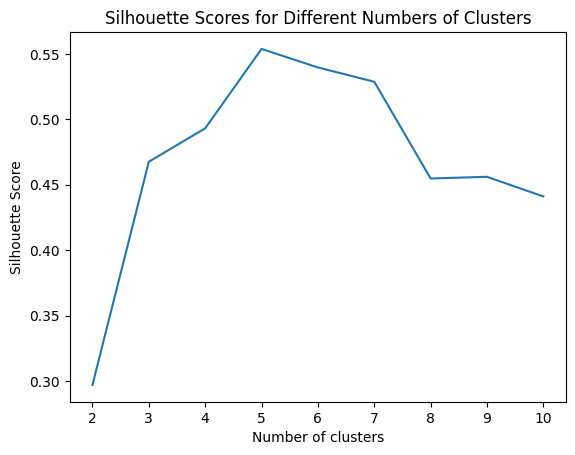

In [ ]:
silhouette_scores = []

for i in range(2, 11):

    model = KMeans(n_clusters=i, n_init=10, random_state=42)

    model.fit(X)

    score = silhouette_score(X, model.labels_)

    silhouette_scores.append(score)

    print(f'Silhouette score for {i} clusters: {score}')

plt.plot(range(2, 11), silhouette_scores)

plt.title('Silhouette Scores for Different Numbers of Clusters')

plt.xlabel('Number of clusters')

plt.ylabel('Silhouette Score')

plt.show()






In [ ]:
# create input data

X=data.iloc[:,3:]

X






,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


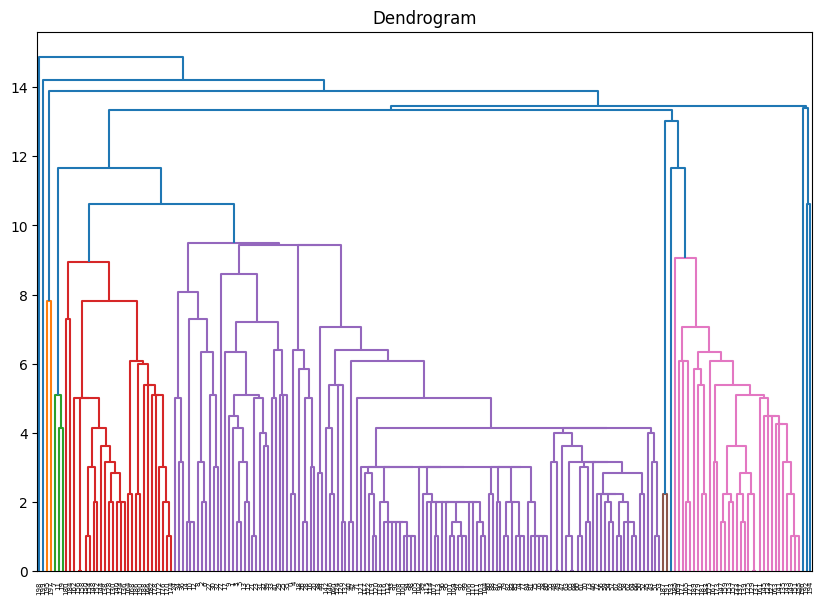

In [ ]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10,7))

plt.title('Dendrogram')

dend=shc.dendrogram(shc.linkage(X,method='single'))






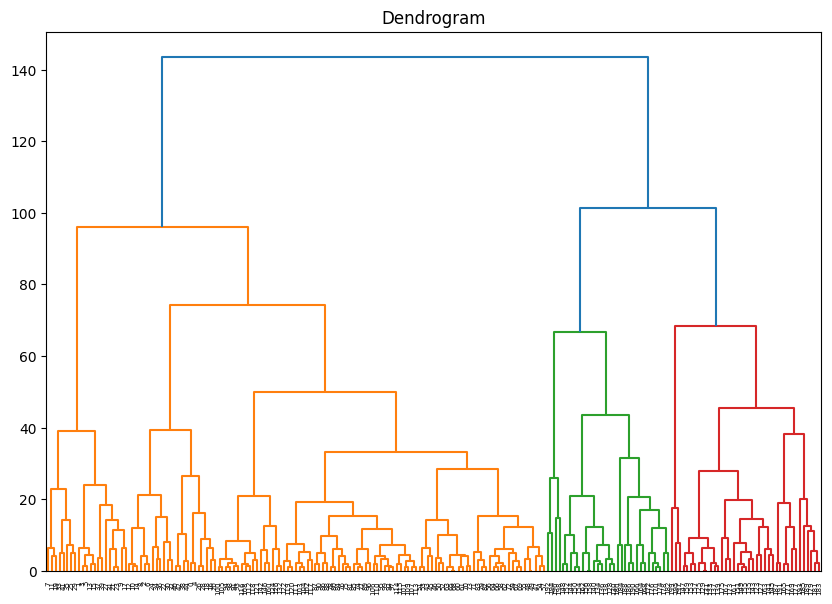

In [ ]:
plt.figure(figsize=(10,7))

plt.title('Dendrogram')

dend=shc.dendrogram(shc.linkage(X,method='complete'))






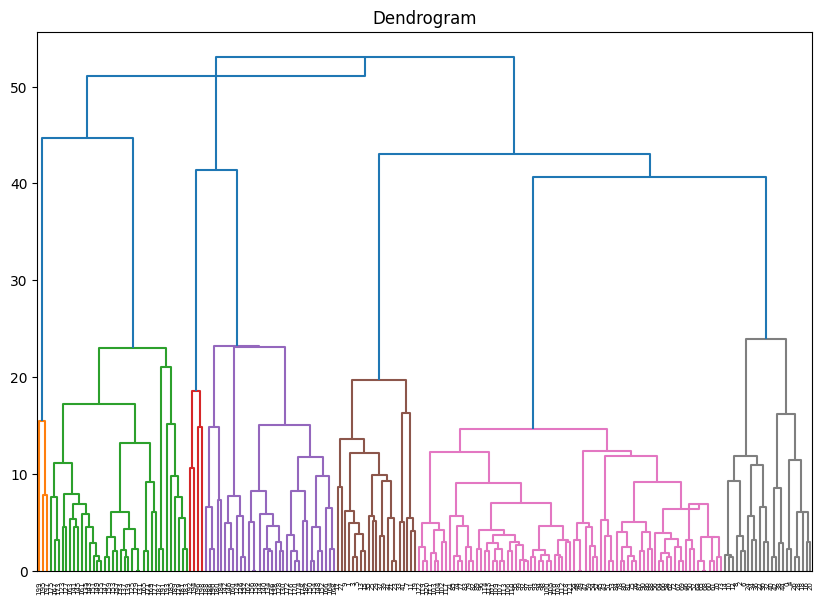

In [ ]:
plt.figure(figsize=(10,7))

plt.title('Dendrogram')

dend=shc.dendrogram(shc.linkage(X,method='centroid'))






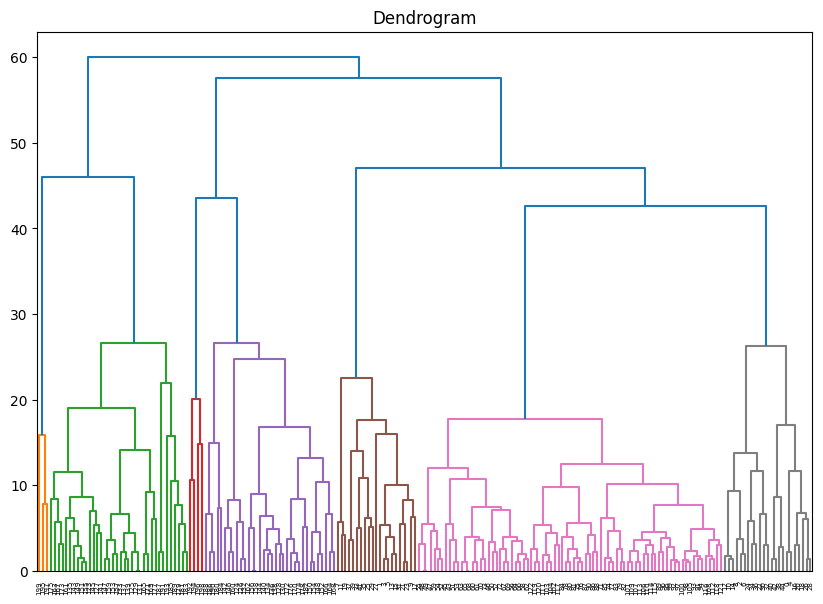

In [ ]:
plt.figure(figsize=(10,7))

plt.title('Dendrogram')

dend=shc.dendrogram(shc.linkage(X,method='average'))






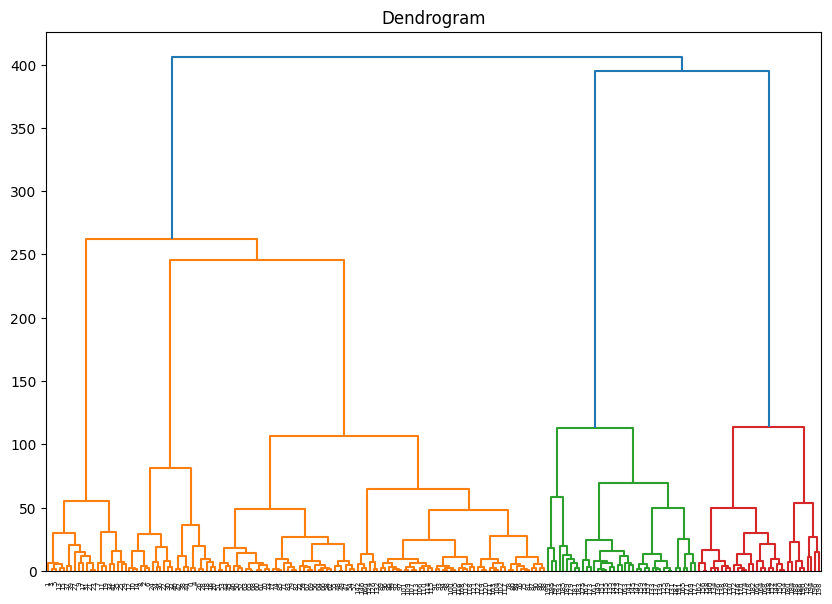

In [ ]:
plt.figure(figsize=(10,7))

plt.title('Dendrogram')

dend=shc.dendrogram(shc.linkage(X,method='ward'))






In [ ]:
# perform clustering

from sklearn.cluster import AgglomerativeClustering

model=AgglomerativeClustering(n_clusters=5,linkage='ward')

labels=model.fit_predict(X)

labels






array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

In [ ]:
X1=data.iloc[:,3:].values






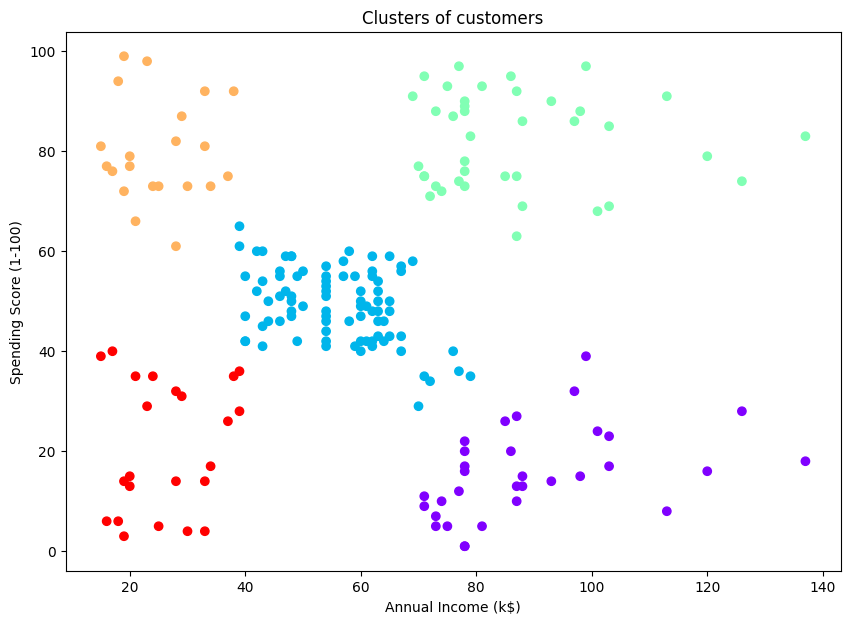

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(X1[:,0],X1[:,1],c=model.labels_,cmap='rainbow')

plt.title('Clusters of customers')

plt.xlabel('Annual Income (k$)')

plt.ylabel('Spending Score (1-100)')

plt.show()






In [ ]:
from sklearn.metrics import silhouette_score

silhouette_score_hier=silhouette_score(X,labels)

silhouette_score_hier






np.float64(0.5529945955148897)